In [24]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [25]:
tickers = ['AAPL', 'MSFT', 'JPM', 'XOM', 'GLD']
prices=yf.download(tickers, start='2021-01-01', end='2026-01-01', auto_adjust=True)
close_prices = prices['Close']
returns = close_prices.pct_change().dropna()

[*********************100%***********************]  5 of 5 completed


In [26]:
weights=np.array([0.2, 0.2, 0.2, 0.2, 0.2])  


In [27]:
portfolio_returns=pd.Series(np.dot(returns, weights), index=returns.index)
portfolio_returns.head()

Date
2021-01-05    0.013985
2021-01-06   -0.000672
2021-01-07    0.020186
2021-01-08   -0.001452
2021-01-11    0.002074
dtype: float64

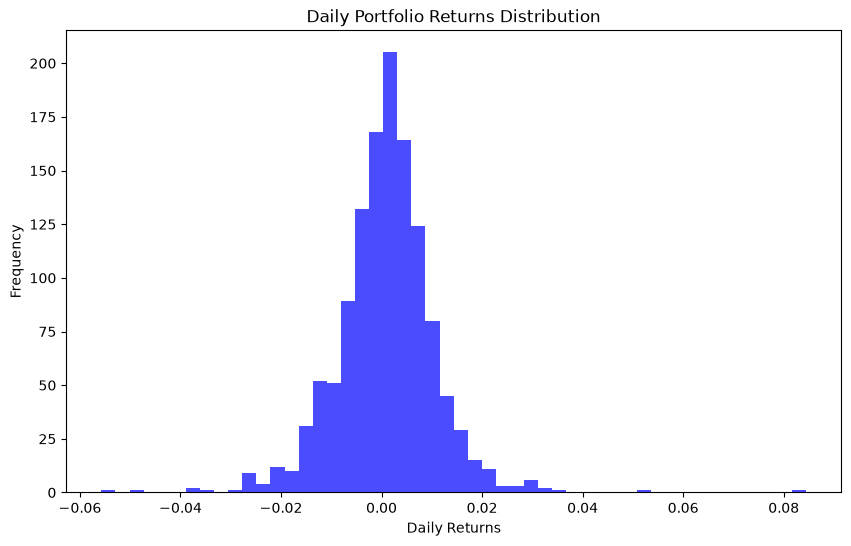

In [28]:
plt.figure(figsize=(10, 6))
plt.hist(portfolio_returns, bins=50, alpha=0.7, color='blue')
plt.title('Daily Portfolio Returns Distribution')
plt.xlabel('Daily Returns')
plt.ylabel('Frequency')
plt.show()

In [29]:
portfolio_returns.describe()

count    1254.000000
mean        0.000872
std         0.009671
min        -0.055728
25%        -0.004023
50%         0.001109
75%         0.006144
max         0.084418
dtype: float64

In [30]:
historical_var_95 = -np.percentile(portfolio_returns, 5)
historical_var_95

np.float64(0.014286229660949418)

In [31]:
mean_return = portfolio_returns.mean()
volatility = portfolio_returns.std()
mean_return, volatility

(np.float64(0.0008720868333232383), np.float64(0.009671186566625774))

In [32]:
z=1.645  
parametric_var_95 = -(mean_return - z * volatility)
parametric_var_95

np.float64(0.01503701506877616)

In [33]:
portfolio_value = 1000000  
historical_var_95_euro = historical_var_95 * portfolio_value
parametric_var_95_euro = parametric_var_95 * portfolio_value
historical_var_95_euro, parametric_var_95_euro

(np.float64(14286.229660949417), np.float64(15037.01506877616))

In [34]:
var_threshold=np.percentile(portfolio_returns, 5)
var_threshold

np.float64(-0.014286229660949418)

In [35]:
tail_losses = portfolio_returns[portfolio_returns <= var_threshold]
tail_losses

Date
2021-01-15   -0.018780
2021-01-29   -0.020910
2021-02-25   -0.021491
2021-03-18   -0.018598
2021-06-18   -0.014445
                ...   
2025-04-04   -0.055728
2025-04-10   -0.025542
2025-09-05   -0.014367
2025-10-10   -0.016163
2025-10-21   -0.015581
Length: 63, dtype: float64

In [36]:
expected_shortfall_95 = -tail_losses.mean()
expected_shortfall_95

np.float64(0.02125780347085745)

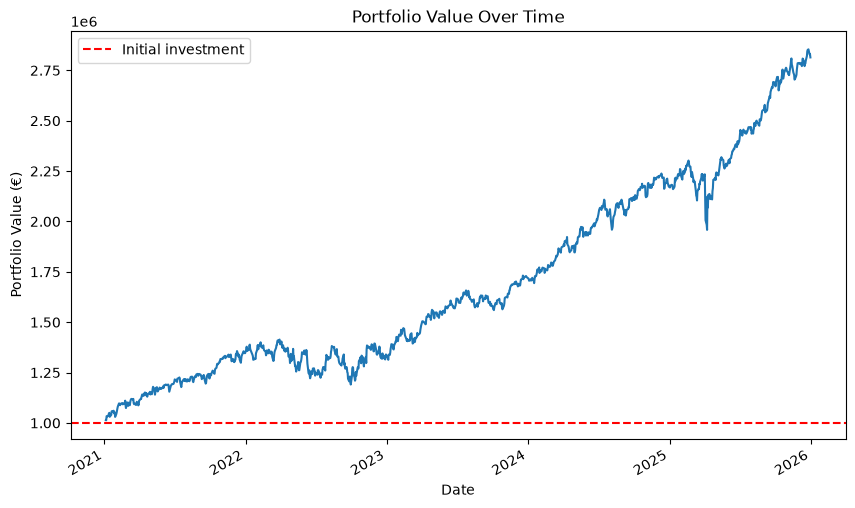

In [37]:
initial_investment = 1000000
portfolio_value = initial_investment * (1 + portfolio_returns).cumprod()
portfolio_value.plot(figsize=(10, 6))
plt.title('Portfolio Value Over Time')
plt.xlabel('Date')
plt.ylabel('Portfolio Value (€)')
plt.axhline(initial_investment, color='red', linestyle='--', label='Initial investment')
plt.legend()
plt.show()

In [38]:
running_peak = portfolio_value.cummax()
drawdown = (portfolio_value - running_peak) / running_peak
drawdown

Date
2021-01-05    0.000000
2021-01-06   -0.000672
2021-01-07    0.000000
2021-01-08   -0.001452
2021-01-11    0.000000
                ...   
2025-12-24    0.000000
2025-12-26    0.000000
2025-12-29   -0.008845
2025-12-30   -0.008484
2025-12-31   -0.014024
Length: 1254, dtype: float64

In [39]:
max_drawdown = drawdown.min()
max_drawdown

np.float64(-0.1578543726760681)

In [40]:
max_drawdown_pct = max_drawdown * 100
max_drawdown_pct

np.float64(-15.785437267606811)

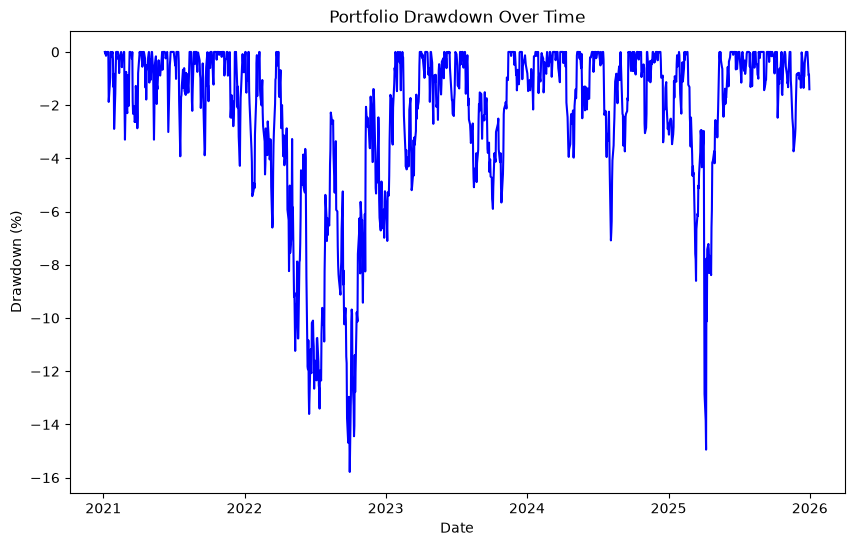

In [41]:
plt.figure(figsize=(10, 6))
plt.plot(drawdown*100, color='blue')
plt.title('Portfolio Drawdown Over Time')
plt.xlabel('Date')
plt.ylabel('Drawdown (%)')
plt.show()

In [42]:
max_drawdown_date = drawdown.idxmin()
max_drawdown_date

Timestamp('2022-09-30 00:00:00')

In [43]:
portfolio_value.loc[max_drawdown_date]

np.float64(1190695.1216562325)

In [44]:
running_peak.loc[max_drawdown_date]

np.float64(1413882.6861096208)

In [45]:
risk_summary=pd.DataFrame({'Metric': ['Historical VaR (95%)', 'Parametric VaR (95%)', 'Expected Shortfall (95%)', 'Max Drawdown'],'Risk':[historical_var_95,parametric_var_95,expected_shortfall_95,max_drawdown_pct]})
risk_summary

,Metric,Risk
0,Historical VaR (95%),0.014286
1,Parametric VaR (95%),0.015037
2,Expected Shortfall (95%),0.021258
3,Max Drawdown,-15.785437


In [46]:
risk_summary['Risk']=risk_summary['Risk']*100
risk_summary

,Metric,Risk
0,Historical VaR (95%),1.428623
1,Parametric VaR (95%),1.503702
2,Expected Shortfall (95%),2.125780
3,Max Drawdown,-1578.543727


#Value at Risk and Expected Shortfall

-The historical 95% one day VaR of the equal weight portfolio was approximately 1.43%. This means that approximately 95% of historical daily portfolio returns were above a loss threshold of 1.43%, while approximately 5% were worse.

-The parametric 95% VaR was approximately 1.50%, which was relatively close to the historical estimate.

-The historical 95% Expected Shortfall was approximately 2.13%. This indicates that when the portfolio experienced returns with the worst 5% of historical observations, the average loss was 2.13%.

-The difference between VaR and Expected Shortfall demonstrates the importance of analysing tail risk. VaR identifies a loss threshold while Expected Shortfall measures the average severity of losses beyond the threshold.

#Maximum Drawdown

-Maximum Drawdown measures the largest percentage decline in portfolio value from a previous peak during the sample period.

-Unlike VaR and Expected Shortfall, which focus primarily on daily downside risk, maximum drawdown captures the cumulative experience of an investor over time.

-The maximum drawdown therefore provides a useful complementary measure of portfolio risk, particularly for understanding the potential magnitude of prolonged declines.